To do:

1. Check dependence of network size on extinction duration
2. Check not only whether the NA converges to the other outcome, but also how fast it does so

In [32]:
# standard preamble for the Notebooks I use
import torch as tc
import igraph as ig
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams

# Enable LaTeX and set Times New Roman as the font
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: Use LaTeX packages
})

from tqdm import tqdm

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

# compact saving of data
import h5py

from src.automata import LLNA
from src.simulation import *
from src.rules import binary_indices, return_equivalent_rule, get_nonequiv_rules, return_life_like_dict
from src.networks import create_2d_torus_lattice, watts_strogatz_rewire
from src.analysis import median_and_percentiles_over_ensemble, mean_field_dens_propagation, derrida_map_analytical, hamming_weight, boolean_sens, mean_field_slope

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


This rule is equivalent to itself.


(<Figure size 1000x180 with 1 Axes>,
 <Axes: title={'center': 'Diagram for LLNA $\\phi^{9}_{488,464}$'}, xlabel="State density $\\rho$ of the node's neighbourhood", ylabel='Node becomes ...'>)

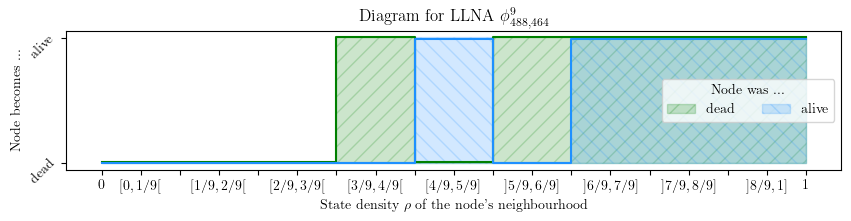

In [2]:
resolution = 9
beta, sigma = (488, 464)
B_set = binary_indices(beta)
S_set = binary_indices(sigma)

# this rule is equivalent to itself
beta_equiv, sigma_equiv = return_equivalent_rule(resolution, B_set, S_set, return_decimals=True)
if (beta, sigma) == (beta_equiv, sigma_equiv):
    print("This rule is equivalent to itself.")

model = LLNA(resolution, B_set, S_set, iso=True)
model.diagram()

Text(0.5, 0.98, 'Rule $\\phi^9_{488,464}$')

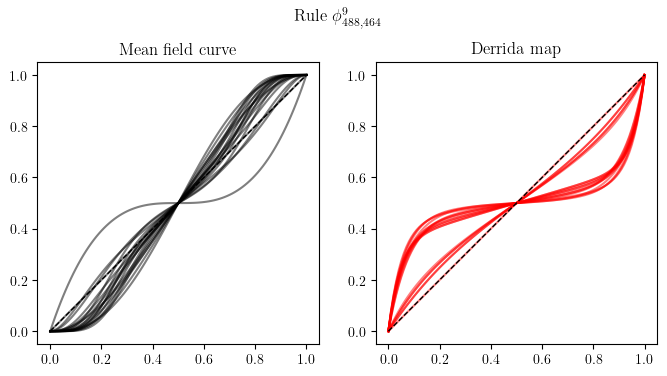

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

rho0_array = np.linspace(0,1,101)
delta0_array = np.linspace(0,1,101)
degrees= np.arange(1,20,1, dtype=int)

rho1_arrays = np.array([mean_field_dens_propagation(resolution, B_set, S_set, rho0_array, degree) for degree in degrees])
delta1_arrays = np.array([derrida_map_analytical(resolution, B_set, S_set, delta0_array, degree) for degree in degrees])

for degree, rho1_array, degree1_array in zip(degrees, rho1_arrays, delta1_arrays):
    axs[0].set_title("Mean field curve")
    axs[0].plot(rho0_array, rho1_array, label=f"Degree {degree}", color='k', alpha=0.5)
    axs[1].set_title("Derrida map")
    axs[1].plot(delta0_array, degree1_array, label=f"Degree {degree}", color='r', alpha=0.5)
for ax in axs:
    ax.plot([0,1], [0,1], lw=1, ls='--', color='k')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_aspect(1)

plt.suptitle(f"Rule $\\phi^{resolution}_{{{beta},{sigma}}}$")

In [4]:
# Parameters
width = 100                  # Grid size (L x L) WATCH OUT with values, becomes intensive fast. 200 takes 10 minutes
num_nodes = width**2
rewiring_prob = 0.2     # Rewiring probability
degree = 8
num_edges = num_nodes*degree//2

# Create toroidal lattice and rewire.
# REWIRING CAN TAKE A WHILE!
lattice_graph = create_2d_torus_lattice(width, degree=degree)
small_world_graph = watts_strogatz_rewire(lattice_graph, rewiring_prob)
random_graph = ig.Graph.Erdos_Renyi(n=num_nodes, m=num_edges) # watts_strogatz_rewire(lattice_graph, 1.)

# find edges
lattice_graph.to_directed()
lattice_edges = tc.tensor(lattice_graph.get_edgelist()).T
lattice_graph.to_undirected()

small_world_graph.to_directed()
small_world_edges = tc.tensor(small_world_graph.get_edgelist()).T
small_world_graph.to_undirected()

random_graph.to_directed()
random_edges = tc.tensor(random_graph.get_edgelist()).T
random_graph.to_undirected()

# save graphs and edges in list
graphs = [lattice_graph, small_world_graph, random_graph]
graph_names = ["Lattice", f"Small World ($p={rewiring_prob}$)", "Random"]
edges = [lattice_edges, small_world_edges, random_edges]

In [5]:
idx = 1
edge = edges[idx]
graph_name = graph_names[idx]

def init_config_with_dens(N, dens):
    # defines a random initial configuration with a fixed state density
    s0 = np.zeros(N, dtype=int)
    s0[:np.round(dens*N).astype(int)] = 1.
    np.random.shuffle(s0)
    return s0

T = 100
num_config = 10
init_dens = 0.5

init_configs = np.array([init_config_with_dens(num_nodes, init_dens) for _ in range(num_config)])
configs = model.forward(edge, tc.tensor(init_configs), T=T).numpy().astype(int)

# put back in L x L shape 
configs = configs.reshape((num_config, T+1, width, width))

In [6]:
# animations
import matplotlib.animation as animation
from IPython.display import HTML
from matplotlib import rcParams
rcParams['animation.embed_limit'] = 256  # Set a higher limit for embedding animations

def make_animation_object(grids, title=None):
    # Set up figure
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(grids[0])
    # Update function for animation
    def update(frame):
        im.set_array(grids[frame])
        ax.set_title(title, fontsize=20)
        ax.set_xticks([]); ax.set_yticks([])
        return [im]
    # Create animation
    ani = animation.FuncAnimation(fig, update, frames=T+1, interval=100)
    plt.close()
    return ani

In [7]:
# show an animation. small world blijft krioelen voor day&night! random ook.
# threshold model wordt heel saai voor small world en voor random network, dus er is wel degelijk iets te zeggen voor het annealed model

example_idx = 0
ani = make_animation_object(configs[example_idx], title=f"{model.__str__(latex=True)} on graph `{graph_name}'")
# ani = make_animation_object(defects[example_idx])

# show inline
HTML(ani.to_jshtml())

In [ ]:
# save some GIFs for future reference

SAVEGIFS = False
life_like_name = '488-464'

if SAVEGIFS:
    for i, config in tqdm(enumerate(configs), total=configs.shape[0]):
        savename = f"animation_llna_smallworld_{life_like_name}_{width}x{width}_T{T}_sample{i}.gif"

        # example_idx = np.random.randint(num_config)
        ani = make_animation_object(config, title=f"{model.__str__(latex=True)} on graph `{graph_name}'")
        # ani = make_animation_object(defects[example_idx])

        # Save animations as GIFs
        loc = '../figures/gifs/'
        ani.save(loc+savename, writer='pillow', fps=24)  # Using Pillow

        # show inline
        # HTML(ani.to_jshtml())

100%|██████████| 10/10 [01:13<00:00,  7.31s/it]


# Introducing defects for tipping the scales

### First for a single initial configuration

In [8]:
# check the final density of the configurations. It should be either 0 or 1.
idx = 0
config = configs[idx]
print(f"The final state density is {np.mean(config[-1])}.")

The final state density is 0.0.


In [9]:
# flatten initial configuration
init_config = config[0].reshape(width**2)

# obtain degrees
degrees = np.array(graphs[1].degree())
sorted_indices = np.argsort(degrees)

# find and report max degrees
max_degree = np.max(degrees)
max_degree_indices = np.where(degrees == max_degree)[0]
max_degree_alive = np.sum(init_config[max_degree_indices])
almost_max_degree_indices = np.where(degrees == max_degree-1)[0]
almost_max_degree_alive = np.sum(init_config[almost_max_degree_indices])
print(f"There are {np.sum(degrees == max_degree)} nodes with the maximum degree {max_degree}. {max_degree_alive} are alive.")
print(f"There are {np.sum(degrees == max_degree-1)} nodes with the degree {max_degree-1}. {almost_max_degree_alive} are alive.")
print(f"")

min_degree = np.min(degrees)
min_degree_indices = np.where(degrees == min_degree)[0]
min_degree_alive = np.sum(init_config[min_degree_indices])
almost_min_degree_indices = np.where(degrees == min_degree+1)[0]
almost_min_degree_alive = np.sum(init_config[almost_min_degree_indices])
print(f"There are {np.sum(degrees == min_degree)} nodes with the minimum degree {min_degree}. {min_degree_alive} are alive.")
print(f"There are {np.sum(degrees == min_degree+1)} nodes with the degree {min_degree+1}. {almost_min_degree_alive} are alive.")

There are 6 nodes with the maximum degree 13. 2 are alive.
There are 38 nodes with the degree 12. 19 are alive.

There are 5 nodes with the minimum degree 4. 3 are alive.
There are 133 nodes with the degree 5. 71 are alive.


In [298]:
def switch_life_to_high_degree(graph, init_config, number_of_switches):
    if number_of_switches<0:
        raise ValueError(f"The number of switches must be a nutural number. Not {number_of_switches}.")
    # get all degrees
    degrees = np.array(graph.degree())
    N = len(init_config)
    if len(degrees) != N:
        raise ValueError(f"The number of nodes and the number of initial states do not match.")
    if number_of_switches > N//2:
        raise ValueError(f"You cannot switch places of more than half of the nodes.")
    # get the indices of all nodes sorted by degree
    sorted_node_indices = np.argsort(degrees)
    sorted_degrees = degrees[sorted_node_indices]
    # find unique degrees
    unique_degrees = np.unique(degrees)
    # Randomize within groups (to avoid other correlations)
    shuffled_sorted_node_indices = np.empty_like(sorted_node_indices)
    start = 0
    for unique_degree in unique_degrees:
        # find where the indices correspond to the current degree value
        val_indices = np.where(sorted_degrees == unique_degree)[0]
        # get the subarray of degrees coresponding to this value
        group = sorted_node_indices[val_indices]
        # randomise the group
        np.random.shuffle(group)
        # glue the pieces back together
        shuffled_sorted_node_indices[start:start + len(group)] = group
        start += len(group)
    # order the initial configuration according to the shuffled degree-sorted indices
    init_config_shuffle_ordered = init_config[shuffled_sorted_node_indices]
    # find the shuffled indices whose node is alive and kill 'em dead
    indices_where_alive = np.where(init_config_shuffle_ordered==1)[0][:number_of_switches]
    init_config_shuffle_ordered[indices_where_alive] = 0
    # same for the high-degree dead nodes that are brought to life
    indices_where_dead  = np.where(init_config_shuffle_ordered==0)[0]
    number_of_dead = len(indices_where_dead)
    indices_where_dead = indices_where_dead[(number_of_dead-number_of_switches):]
    init_config_shuffle_ordered[indices_where_dead] = 1
    # undo the ordering
    init_config_switched = init_config_shuffle_ordered[np.argsort(shuffled_sorted_node_indices)]
    return init_config_switched

In [22]:
graph = graphs[1]
total=100

init_config_stack = init_config.copy()
for number_of_switches in tqdm(range(total), total=total):
    init_config_switched = switch_life_to_high_degree(graph, init_config, number_of_switches)
    init_config_stack = np.vstack((init_config_stack, init_config_switched))

100%|██████████| 100/100 [00:17<00:00,  5.66it/s]


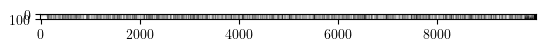

In [27]:
degrees = np.array(graphs[1].degree())
sorted_node_indices = np.argsort(degrees)

plt.imshow(init_config_stack[:,sorted_node_indices], cmap='Greys')

In [25]:
# run with new initial condition

edge = edges[1] # small-world
T = 100
num_new_runs = 100

configs_switched = model.forward(edge, tc.tensor(init_config_stack[:num_new_runs]), T=T).numpy().astype(int)

# put back in L x L shape 
configs_switched = configs_switched.reshape((num_new_runs, T+1, width, width))

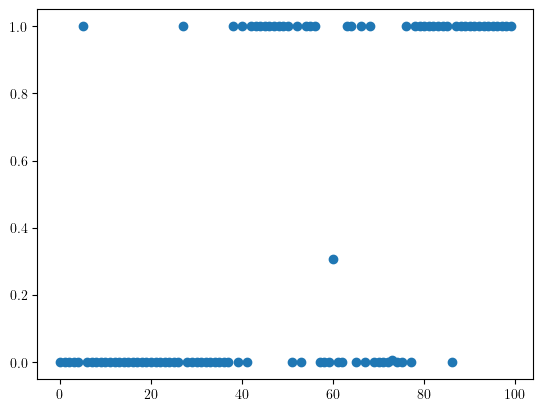

In [26]:
# plt.scatter(range(100), np.mean(configs_switched[:,-1], axis=(1,2)))

means = np.mean(configs_switched[:, -1], axis=(1, 2))  # shape: (100,)
plt.scatter(range(100), means)

# Reshape into 10 bins of size 10
binned_means = means.reshape(20, 5).mean(axis=1)  # shape: (10,)

# X positions for the bins (e.g., center of each bin)
x = np.arange(0, 100, 5)

# Plot as bar graph
# plt.bar(x+.5, binned_means, width=4, align='edge')  # or align='center' if you prefer
# plt.xlabel("Bit switches based on degree (binned per 5)")
# plt.ylabel("Fraction of runs that end in full life")
# plt.title(None)
# plt.show()

Now do this for many more graphs, many more initial configurations, and many more structural node properties! And make sure to average over the switches (cause the order is chosen randomly as well). Also, make sure to compare to random switching.

### 1. Make many small-world graphs

In [44]:
# Parameters
width = 30                  # Grid size (L x L) WATCH OUT with values, becomes intensive fast. 200 takes 10 minutes
num_nodes = width**2
num_graphs = 30
rewiring_prob = 0.2         # Rewiring probability
degree = 8
num_edges = num_nodes*degree//2

# Create toroidal lattice and rewire.
# REWIRING CAN TAKE A WHILE!
lattice_graph = create_2d_torus_lattice(width, degree=degree)
small_world_graph_array = np.array([watts_strogatz_rewire(lattice_graph, rewiring_prob) for _ in tqdm(range(num_graphs), total=num_graphs)])

# find edges
small_world_edges_list = []
for small_world_graph in small_world_graph_array:
    small_world_graph.to_directed()
    small_world_edges = tc.tensor(small_world_graph.get_edgelist()).T
    small_world_edges_list.append(small_world_edges)
    small_world_graph.to_undirected()
# small_world_edges_array = np.array(small_world_edges_list)

100%|██████████| 30/30 [00:05<00:00,  5.76it/s]


### 2. Make multiple runs on these graphs

In [45]:
def init_config_with_dens(N, dens):
    # defines a random initial configuration with a fixed state density
    s0 = np.zeros(N, dtype=int)
    s0[:np.round(dens*N).astype(int)] = 1.
    np.random.shuffle(s0)
    return s0

T = 100
num_config = 10
init_dens = 0.5

configs_list = []
for small_world_edges in tqdm(small_world_edges_list, total=num_graphs):
    # run the network automaton
    init_configs = np.array([init_config_with_dens(num_nodes, init_dens) for _ in range(num_config)])
    configs = model.forward(small_world_edges, tc.tensor(init_configs), T=T).numpy().astype(int)

    # put back in L x L shape 
    configs = configs.reshape((num_config, T+1, width, width))
    configs_list.append(configs)
configs_array = np.array(configs_list)

100%|██████████| 30/30 [00:13<00:00,  2.27it/s]


In [76]:
ani = make_animation_object(configs_array[0,7], title=f"{model.__str__(latex=True)} on graph Small World graph")
# ani = make_animation_object(defects[example_idx])

# show inline
HTML(ani.to_jshtml())

### 3. Select all combinations (graph, init_config) that result in extinction

Observation: there is a natural spread over the graphs. The capacity of going extinct is not super dependent on the particular adjacency matrix.

In [ ]:
extinction_automata_per_graph = []
for idx, small_world_graph in enumerate(small_world_graph_array):
    configs_per_graph = configs_array[idx]
    configs_mask = np.mean(configs_per_graph[:,-1], axis=(1,2))==0
    extinction_automata_per_graph.append(configs_per_graph[configs_mask])

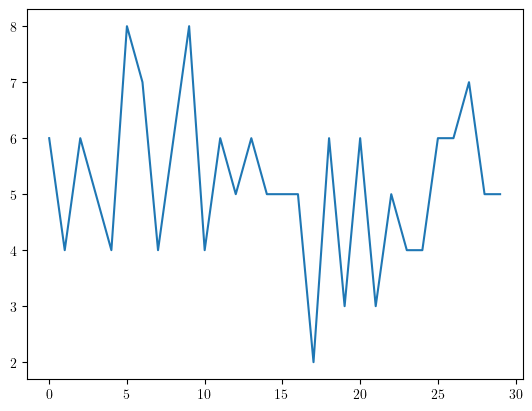

In [72]:
extinctions_per_graph = [extinction_automata_per_graph[idx].shape[0] for idx in range(num_graphs)]
plt.plot(extinctions_per_graph)

### 4. Run over all graphs and intial configurations that lead to extinction, and try to avoid extinction

Observation: a lot of systems will already flip their behaviour even after a single state switch!

(array([  0.,   0.,   0.,   1.,   9.,  64., 223., 323., 196.,  68.,  14.,
          2.,   0.]),
 array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14.]),
 <BarContainer object of 13 artists>)

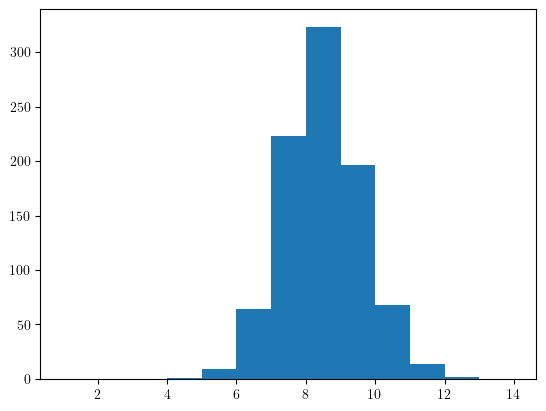

In [85]:
plt.hist(small_world_graph_array[2].degree(), bins=range(1,15))

In [421]:
# this creates a list for entries per graph.
# each entry has dimensions (max_switches, extinctions_per_graph, T+1, width, width)

max_switches = 100
configs_switched_list = []
for extinction_automata, small_world_graph, small_world_edges in tqdm(zip(extinction_automata_per_graph, small_world_graph_array, small_world_edges_list), total=num_graphs):
    extinctions_per_graph = extinction_automata.shape[0]
    init_configs = extinction_automata[:,0].reshape(extinctions_per_graph, width**2)
    init_configs_switched = []
    # also run over no-switch (makes life a little easier)
    for number_of_switches in range(0,max_switches+1):
        # add them together so we can use the parallellisation of the GNN
        for init_config in init_configs:
            init_config_switched = switch_life_to_high_degree(small_world_graph, init_config, number_of_switches)
            init_configs_switched.append(init_config_switched)
    init_configs_switched = np.array(init_configs_switched)
    configs_switched = model.forward(small_world_edges, tc.tensor(init_configs_switched), T=T).numpy().astype(int)
    configs_switched = configs_switched.reshape(max_switches+1, extinctions_per_graph, T+1, width, width)
    configs_switched_list.append(configs_switched)

100%|██████████| 30/30 [03:09<00:00,  6.31s/it]


### 5. Show an example of a single switch that can change the entire outcome

In [ ]:
graph_idx = 0
first_idx_with_extinction = 0
first_idx_with_full_population = 0
while True:
    config_with_extinction = configs_array[graph_idx,first_idx_with_extinction]
    if np.sum(config_with_extinction[-1])==0:
        config_switched_with_full_population = configs_switched_list[graph_idx][1,first_idx_with_full_population]
        if np.sum(config_switched_with_full_population[-1])==num_nodes:
            break
        first_idx_with_full_population += 1
    first_idx_with_extinction += 1

In [452]:
# original animation

ani = make_animation_object(config_with_extinction, title=f"{model.__str__(latex=True)} on graph Small World graph")
# ani = make_animation_object(defects[example_idx])

# show inline
HTML(ani.to_jshtml())

In [454]:
# animation with tiny change

ani = make_animation_object(config_switched_with_full_population, title=f"{model.__str__(latex=True)} on graph Small World graph")
# ani = make_animation_object(defects[example_idx])

# show inline
HTML(ani.to_jshtml())

In [455]:
# animation of the difference pattern

configs_defect = np.bitwise_xor(config_with_extinction, config_switched_with_full_population)

ani = make_animation_object(configs_defect, title=f"{model.__str__(latex=True)} on graph Small World graph")
# ani = make_animation_object(defects[example_idx])

# show inline
HTML(ani.to_jshtml())

By the way, I checked whether this is identical to running the defect as an initial condition. But that's certainly not the case.

### 6. Make a scatter plot showing the average influence of switching states

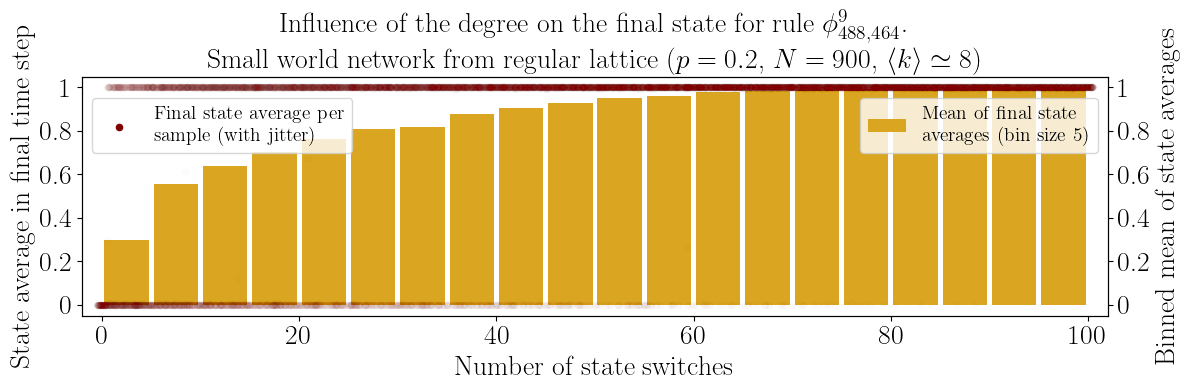

In [456]:
fig, ax1 = plt.subplots(1,1,figsize=(12,4))
fontsize=20
# Create the secondary y-axis
ax2 = ax1.twinx()

alpha=0.01

# open list where all y values are kept (which we will average over later)
y_vals_total = []
# loop over the 30 graphs
for i, configs_switched in enumerate(configs_switched_list):
    # loop over the initial conditions that led to extinction
    number_of_extinctions = configs_switched.shape[1]
    for sample_idx in range(number_of_extinctions):
        hjitter = np.random.random(max_switches+1)-0.5
        x_vals = np.arange(max_switches+1)+hjitter
        y_vals = np.mean(configs_switched[:,sample_idx,-1], axis=(1,2))
        y_vals_total.append(y_vals)
        label=None
        if i==0 and sample_idx==0:
            label='Final state average per\nsample (with jitter)'
        ax1.scatter(x_vals, y_vals, color='maroon', alpha=alpha, s=20, label=label, zorder=10)

# Average over all samples
y_vals_avg = np.mean(y_vals_total, axis=0)  # shape: (max_switches + 1,)

# Bin into intervals of 5
bin_width = 5
bins = np.arange(0, max_switches + 2, bin_width)  # +2 to include max_switches
bin_centers = (bins[:-1] + bins[1:]) / 2

binned_means = []
for i in range(len(bins) - 1):
    start, end = bins[i], bins[i+1]
    bin_avg = np.mean(y_vals_avg[start:end])
    binned_means.append(bin_avg)

# Overlay bar chart
ax2.bar(bin_centers, binned_means, width=bin_width*0.9, color='goldenrod', alpha=1, zorder=0, label=f'Mean of final state\naverages (bin size ${bin_width}$)')

# make axis pretty
ax1.set_ylim(-0.05, 1.05)
ax2.set_ylim(-0.05, 1.05)
ax1.set_xlim(-2, 102)
xticks = [0, 20, 40, 60, 80, 100]
yticks = [0, .2, .4, .6, .8, 1]
ax1.set_xticks(xticks)
ax1.set_xticklabels(xticks, fontsize=fontsize)
ax1.set_yticks(yticks)
ax2.set_yticks(yticks)
ax1.set_yticklabels(yticks, fontsize=fontsize)
ax2.set_yticklabels(yticks, fontsize=fontsize)
ax1.set_xlabel("Number of state switches", fontsize=fontsize)
ax1.set_ylabel(f"State average in final time step", fontsize=fontsize)
ax2.set_ylabel(f"Binned mean of state averages", fontsize=fontsize)

legend = ax1.legend(loc='upper left', bbox_to_anchor=(0,.95), fontsize=fontsize-6)
for handle in legend.legend_handles:
    handle.set_alpha(1)
ax2.legend(loc='upper right', bbox_to_anchor=(1,.95), fontsize=fontsize-6)

# make sure the scatter plot is in front of the bar plot
ax1.set_zorder(2)
ax2.set_zorder(1)
ax1.patch.set_visible(False)  # This is critical!

# set a title
ax1.set_title(f"Influence of the degree on the final state for rule {model.__str__(latex=True)}.\nSmall world network from regular lattice ($p=0.2$, $N={num_nodes}$, $\\langle k \\rangle \\simeq 8$)", fontsize=fontsize)

fig.tight_layout()